#  VisionML – Intelligent Machine Learning Platform

## End-to-End House Price Prediction using Machine Learning

###  Project Overview

VisionML is an end-to-end Machine Learning platform designed to predict house prices using advanced regression techniques. This project follows a complete ML workflow, starting from data collection and preprocessing to model training, evaluation, and deployment.

The primary objective is to build a robust regression model capable of accurately predicting house prices based on various property features.

This project also serves as a production-ready Machine Learning application by integrating a FastAPI backend and a modern frontend in the later stages.

---

##  Project Objectives

- Understand the dataset and business problem
- Perform Exploratory Data Analysis (EDA)
- Clean and preprocess the data
- Handle missing values and outliers
- Engineer meaningful features
- Train multiple regression models
- Compare model performance
- Optimize the best-performing model
- Save the trained model using Joblib
- Build REST APIs using FastAPI
- Develop an interactive frontend dashboard

---

##  Technology Stack

### Programming Language
- Python

### Data Analysis
- Pandas
- NumPy

### Data Visualization
- Matplotlib
- Seaborn

### Machine Learning
- Scikit-learn
- XGBoost

### Backend
- FastAPI

### Frontend
- Next.js
- Tailwind CSS

### Deployment
- Render
- Vercel

---

##  Dataset

**Dataset Name:** House Prices – Advanced Regression Techniques

**Target Variable:** SalePrice

The dataset contains information about residential homes, including property characteristics such as area, number of rooms, neighborhood, construction quality, garage details, and many other features used to predict the final sale price.

---

##  Workflow

1. Import Libraries
2. Load Dataset
3. Understand Dataset
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Data Preprocessing
8. Model Training
9. Hyperparameter Tuning
10. Model Evaluation
11. Save Best Model
12. Build FastAPI Backend
13. Build Frontend
14. Deployment

---

In [1]:
# ============================================
# VisionML - House Price Prediction
# Project Initialization
# ============================================

print("=" * 60)
print("VisionML - Intelligent Machine Learning Platform")
print("End-to-End House Price Prediction")
print("=" * 60)

VisionML - Intelligent Machine Learning Platform
End-to-End House Price Prediction


#  Import Required Libraries

Machine Learning projects rely on multiple libraries for data manipulation,
visualization, preprocessing, model building, and evaluation.

To keep the notebook clean and maintainable, the libraries are organized into
logical categories.

### Categories

- Standard Libraries
- Data Manipulation
- Data Visualization
- Machine Learning
- Model Evaluation
- Model Persistence

In [2]:
# ==========================================================
# Standard Libraries
# ==========================================================
import warnings
warnings.filterwarnings("ignore")
# ==========================================================
# Data Manipulation
# ==========================================================
import numpy as np
import pandas as pd
# ==========================================================
# Data Visualization
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
# Plot Settings
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
# ==========================================================
# Machine Learning
# ==========================================================
from sklearn.model_selection import train_test_split
# ==========================================================
# Model Evaluation
# ==========================================================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# ==========================================================
# Model Persistence
# ==========================================================
import joblib
print("All libraries imported successfully.")

All libraries imported successfully.


#  Load Dataset

In this section, we load the training and testing datasets into Pandas DataFrames.

The training dataset contains both input features and the target variable (`SalePrice`), while the testing dataset contains only input features and is primarily used for making predictions.

After loading the datasets, we will verify:

- Dataset dimensions
- Feature count
- Target variable availability
- Initial data preview

In [3]:
# ==========================================================
# Load Training and Testing Dataset
# ==========================================================
train_path = "../dataset/train.csv"
test_path = "../dataset/test.csv"
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print("Dataset loaded successfully.")

Dataset loaded successfully.


#  Dataset Dimensions

The shape of a dataset tells us:

- Number of rows (observations)
- Number of columns (features)

Understanding the dataset dimensions is the first step before performing data analysis.

In [4]:
# Training Dataset Shape
print("Training Dataset Shape :", train_df.shape)

# Testing Dataset Shape
print("Testing Dataset Shape :", test_df.shape)

Training Dataset Shape : (1460, 81)
Testing Dataset Shape : (1459, 80)


#  Preview the Dataset

Displaying the first five records helps us understand:

- Feature names
- Data types (visually)
- Target column
- Overall dataset structure

In [5]:
# First 5 rows of Training Dataset
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
# First 5 rows of Testing Dataset
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


#  Dataset Understanding

Before performing any preprocessing or model training, it is important to understand the dataset thoroughly.

In this section, we will explore:

- Dataset information
- Column names
- Data types
- Statistical summary
- Missing values
- Duplicate records

A proper understanding of the dataset helps in selecting the right preprocessing and machine learning techniques.

In [7]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("Training Dataset Information")
print("=" * 60)

train_df.info()

Training Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int

In [8]:
# ==========================================================
# Dataset Statistics
# ==========================================================

train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [9]:
# ==========================================================
# Display All Column Names
# ==========================================================

print("Total Features :", len(train_df.columns))
print()
for column in train_df.columns:
    print(column)

Total Features : 81

Id
MSSubClass
MSZoning
LotFrontage
LotArea
Street
Alley
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
OverallQual
OverallCond
YearBuilt
YearRemodAdd
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
MasVnrArea
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinSF1
BsmtFinType2
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
Heating
HeatingQC
CentralAir
Electrical
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
KitchenQual
TotRmsAbvGrd
Functional
Fireplaces
FireplaceQu
GarageType
GarageYrBlt
GarageFinish
GarageCars
GarageArea
GarageQual
GarageCond
PavedDrive
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
PoolQC
Fence
MiscFeature
MiscVal
MoSold
YrSold
SaleType
SaleCondition
SalePrice


In [10]:
# ==========================================================
# Check Duplicate Records
# ==========================================================

duplicates = train_df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [11]:
# ==========================================================
# Missing Values
# ==========================================================

missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [12]:
# ==========================================================
# Missing Values Percentage
# ==========================================================
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100
missing_percentage = missing_percentage[ missing_percentage > 0]
missing_percentage.sort_values(ascending=False).round(2)

PoolQC          99.52
MiscFeature     96.30
Alley           93.77
Fence           80.75
MasVnrType      59.73
FireplaceQu     47.26
LotFrontage     17.74
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
BsmtExposure     2.60
BsmtFinType2     2.60
BsmtQual         2.53
BsmtCond         2.53
BsmtFinType1     2.53
MasVnrArea       0.55
Electrical       0.07
dtype: float64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is one of the most important stages of a Machine Learning project.

The objective of EDA is to understand the underlying patterns, relationships, distributions, and anomalies present in the dataset before applying any machine learning algorithm.

In this section, we will analyze:

- Target Variable Distribution
- Statistical Summary
- Skewness
- Correlation
- Numerical Features
- Categorical Features
- Outliers
- Feature Relationships

In [13]:
# ==========================================================
# Target Variable Overview
# ==========================================================
train_df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Understanding the Target Variable

The target variable in this project is **SalePrice**, which represents the final selling price of a house.

Before training a regression model, it is important to analyze its distribution and identify any skewness or outliers.

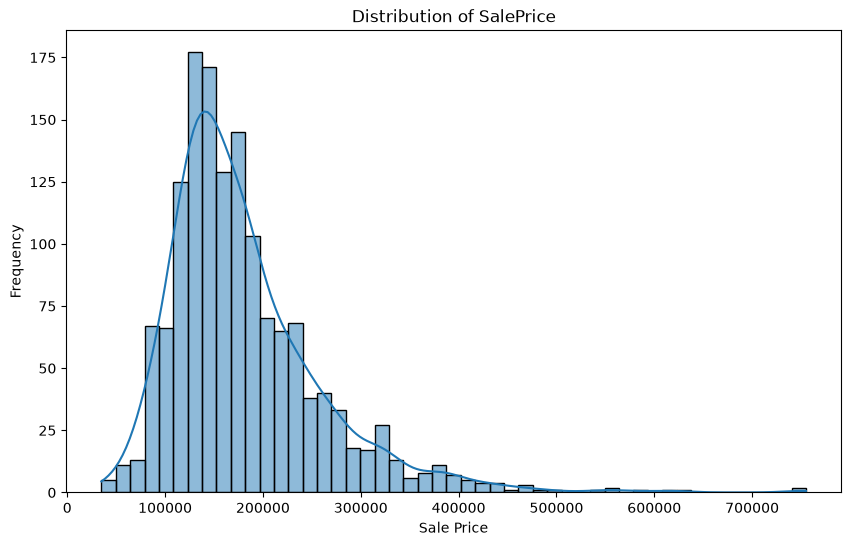

In [14]:
# ==========================================================
# Distribution of Target Variable
# ==========================================================
plt.figure(figsize=(10,6))
sns.histplot(train_df["SalePrice"],kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

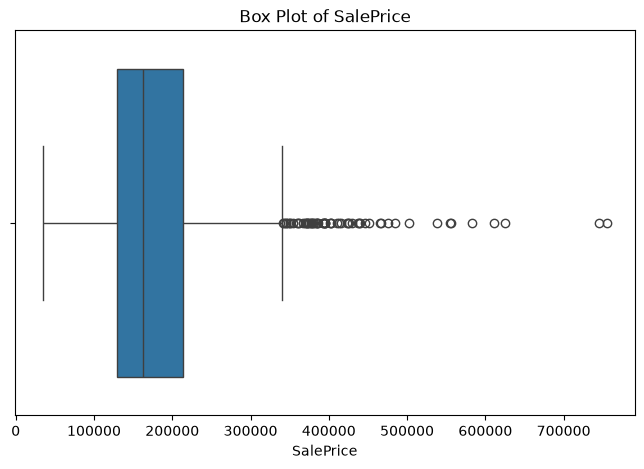

In [15]:
# ==========================================================
# Box Plot
# ==========================================================
plt.figure(figsize=(8,5))
sns.boxplot(x=train_df["SalePrice"])
plt.title("Box Plot of SalePrice")
plt.show()

In [16]:
# ==========================================================
# Skewness
# ==========================================================
skewness = train_df["SalePrice"].skew()
print("Skewness :", round(skewness,2))

Skewness : 1.88


##  Interpretation of Skewness

Skewness measures the symmetry of a distribution.

- Skewness ≈ 0 → Normally Distributed
- Skewness > 0 → Right-Skewed Distribution
- Skewness < 0 → Left-Skewed Distribution

The SalePrice feature is positively skewed, which indicates that most houses are sold at lower prices while a smaller number of houses have very high selling prices.

This is common in real estate datasets.

In [17]:
# ==========================================================
# Mean vs Median
# ==========================================================

print("Mean   :", round(train_df["SalePrice"].mean(),2))
print("Median :", round(train_df["SalePrice"].median(),2))

Mean   : 180921.2
Median : 163000.0


# Feature Analysis

Feature analysis helps us understand the characteristics of each variable in the dataset.

In this section, we will:

- Separate numerical and categorical features
- Identify the target variable
- Understand feature distribution
- Analyze correlations
- Prepare the dataset for preprocessing

In [18]:
# ==========================================================
# Number of Rows and Columns
# ==========================================================

print(f"Rows    : {train_df.shape[0]}")
print(f"Columns : {train_df.shape[1]}")

Rows    : 1460
Columns : 81


In [19]:
# ==========================================================
# Separate Numerical and Categorical Features
# ==========================================================
numerical_features = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = train_df.select_dtypes(include=["object"]).columns.tolist()
print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 38
Categorical Features : 43


In [20]:
# ==========================================================
# Display Numerical Features
# ==========================================================
print("Numerical Features\n")
for feature in numerical_features:
    print(feature)

Numerical Features

Id
MSSubClass
LotFrontage
LotArea
OverallQual
OverallCond
YearBuilt
YearRemodAdd
MasVnrArea
BsmtFinSF1
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
TotRmsAbvGrd
Fireplaces
GarageYrBlt
GarageCars
GarageArea
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
MiscVal
MoSold
YrSold
SalePrice


In [21]:
# ==========================================================
# Display Categorical Features
# ==========================================================
print("Categorical Features\n")
for feature in categorical_features:
    print(feature)

Categorical Features

MSZoning
Street
Alley
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
PoolQC
Fence
MiscFeature
SaleType
SaleCondition


In [22]:
# ==========================================================
# Target Variable
# ==========================================================
target = "SalePrice"
print("Target Variable :", target)

Target Variable : SalePrice


## Correlation Analysis

Correlation measures the strength and direction of the relationship between numerical features.

Values range from **-1 to +1**:

- +1 → Strong Positive Correlation
- 0 → No Correlation
- -1 → Strong Negative Correlation

Understanding correlations helps us identify the most influential features for predicting house prices.

In [23]:
# ==========================================================
# Correlation with Target Variable
# ==========================================================
correlation = train_df.corr(numeric_only=True)["SalePrice"]
correlation = correlation.sort_values(ascending=False)
correlation.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

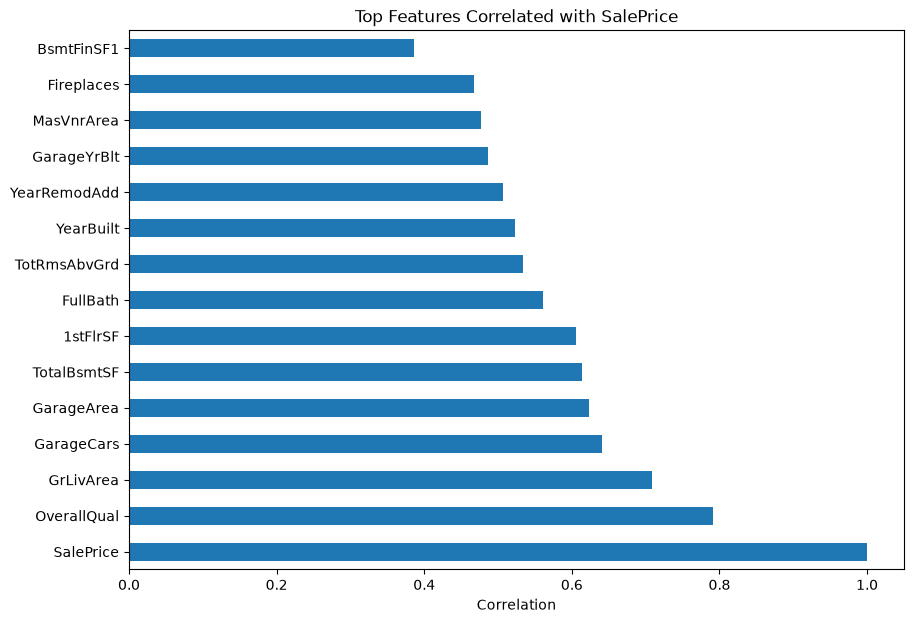

In [24]:
# ==========================================================
# Top 15 Correlated Features
# ==========================================================
top_features = correlation.head(15)
plt.figure(figsize=(10, 7))
top_features.plot(kind="barh")
plt.title("Top Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.show()

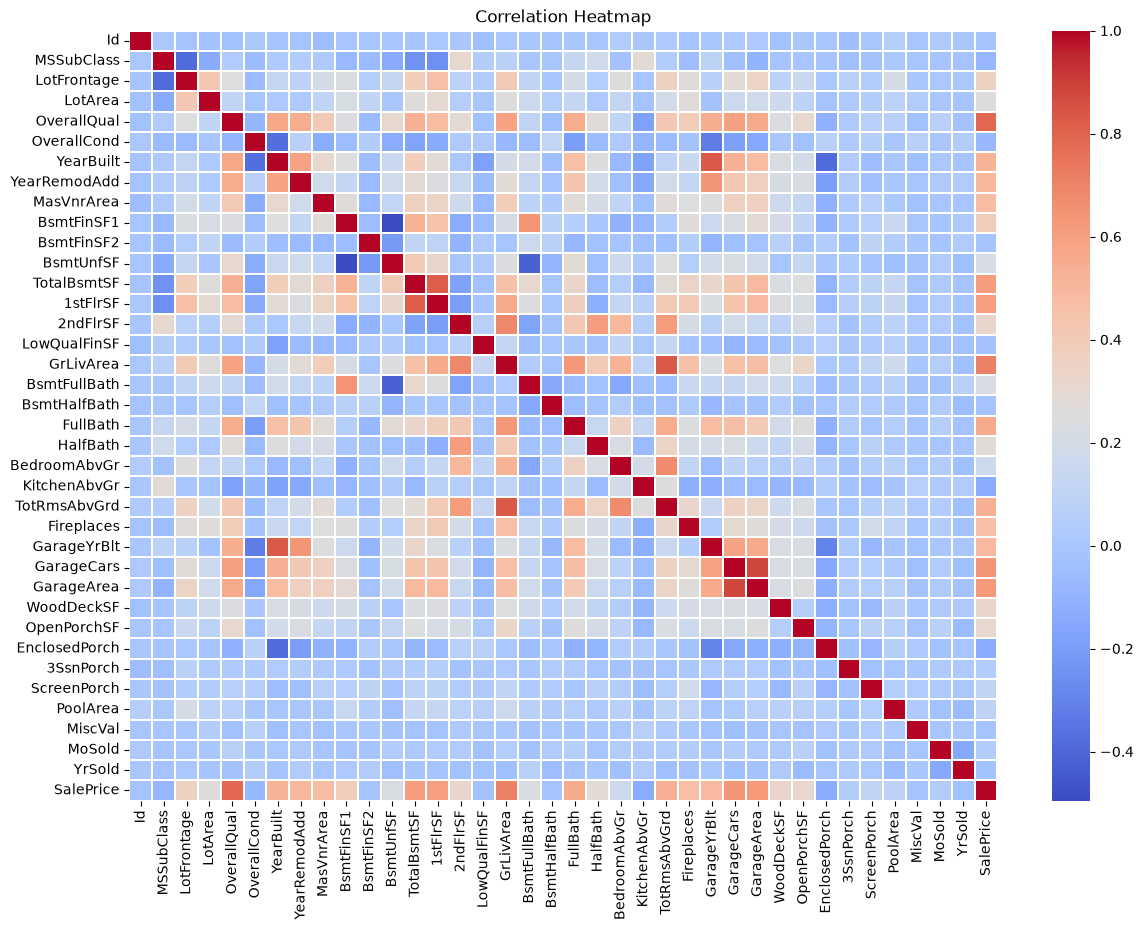

In [25]:
# ==========================================================
# Correlation Heatmap
# ==========================================================
plt.figure(figsize=(14, 10))
sns.heatmap(train_df[numerical_features].corr(),cmap="coolwarm",linewidths=0.2)
plt.title("Correlation Heatmap")
plt.show()

# Data Cleaning & Missing Value Treatment

Real-world datasets often contain missing values, inconsistent records, and unnecessary features.

Before training a machine learning model, it is essential to clean the dataset carefully.

In this section, we will:

- Create a working copy of the dataset
- Identify missing values
- Calculate missing value percentages
- Drop features with excessive missing values
- Prepare the dataset for imputation

In [26]:
# ==========================================================
# Create Working Copies
# ==========================================================

train = train_df.copy()
test = test_df.copy()

print("Working copies created successfully.")

Working copies created successfully.


In [27]:
# ==========================================================
# Missing Values Summary
# ==========================================================
missing = train.isnull().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending=False)
missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [28]:
# ==========================================================
# Missing Value Percentage
# ==========================================================
missing_percent = (train.isnull().mean() * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]
missing_percent.head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [29]:
# ==========================================================
# Missing Values Table
# ==========================================================
missing_table = pd.DataFrame({"Missing Count": train.isnull().sum(),"Missing %": (train.isnull().mean() * 100 )})
missing_table = missing_table[missing_table["Missing Count"] > 0]
missing_table.sort_values(by="Missing %",ascending=False)

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


##  Columns with Very High Missing Values

Some features contain an extremely high percentage of missing values.

Instead of imputing thousands of missing records, it is often more practical to remove such features if they contribute little to model performance.

In this project, columns with more than **80% missing values** will be removed.

In [30]:
# ==========================================================
# Columns with More Than 80% Missing Values
# ==========================================================
high_missing = missing_percent[missing_percent > 80]
high_missing

PoolQC         99.520548
MiscFeature    96.301370
Alley          93.767123
Fence          80.753425
dtype: float64

In [31]:
# ==========================================================
# Drop High Missing Columns
# ==========================================================
drop_columns = high_missing.index.tolist()
train.drop(columns=drop_columns,inplace=True)
test.drop(columns=drop_columns,inplace=True)
print("Dropped Columns")
print(drop_columns)

Dropped Columns
['PoolQC', 'MiscFeature', 'Alley', 'Fence']


In [32]:
# ==========================================================
# Dataset Shape After Dropping Columns
# ==========================================================
print(train.shape)
print(test.shape)

(1460, 77)
(1459, 76)


#  Missing Value Imputation

Missing values are one of the most common challenges in real-world datasets.

Instead of removing every missing record, we replace missing values using
appropriate statistical techniques.

### Strategy

- Numerical Features → Median
- Categorical Features → Mode

Using different strategies for different data types helps preserve the
distribution of the data and improves model performance.

In [33]:
# ==========================================================
# Separate Numerical and Categorical Columns
# ==========================================================
numerical_cols = train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = train.select_dtypes(include=["object"]).columns
print("Numerical Columns :", len(numerical_cols))
print("Categorical Columns :", len(categorical_cols))

Numerical Columns : 38
Categorical Columns : 39


In [34]:
# ==========================================================
# Fill Missing Values in Numerical Features
# ==========================================================

for column in numerical_cols:
    median_value = train[column].median()
    train[column] = train[column].fillna(median_value)
    if column in test.columns:
        test[column] = test[column].fillna(median_value)
print("Numerical missing values handled successfully.")

Numerical missing values handled successfully.


In [35]:
# ==========================================================
# Fill Missing Values in Categorical Features
# ==========================================================

for column in categorical_cols:
    mode_value = train[column].mode()[0]
    train[column] = train[column].fillna(mode_value)
    if column in test.columns:
        test[column] = test[column].fillna(mode_value)
print("Categorical missing values handled successfully.")

Categorical missing values handled successfully.


In [36]:
# ==========================================================
# Verify Missing Values
# ==========================================================
print("Training Missing Values :", train.isnull().sum().sum())
print("Testing Missing Values :", test.isnull().sum().sum())

Training Missing Values : 0
Testing Missing Values : 0


## Missing Value Treatment Completed

All missing values have now been handled using suitable imputation techniques.

The dataset is now complete and ready for the next preprocessing stages, including feature engineering and encoding.

#  Feature Engineering

Feature Engineering is the process of creating new features or transforming existing features to improve the performance of machine learning models.

A well-engineered dataset often has a greater impact on model performance than simply choosing a more complex algorithm.

In this section, we will:

- Remove unnecessary columns
- Separate features and target
- Prepare the dataset for encoding
- Create meaningful features (where appropriate)

In [37]:
# ==========================================================
# Separate Features and Target
# ==========================================================
X = train.drop(columns=["SalePrice"])
y = train["SalePrice"]
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (1460, 76)
Target Shape   : (1460,)


In [38]:
# ==========================================================
# Target Variable Statistics
# ==========================================================
print(y.describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [39]:
# ==========================================================
# Numerical and Categorical Features
# ==========================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
print("Numeric Features     :", len(numeric_features))
print("Categorical Features :", len(categorical_features))

Numeric Features     : 37
Categorical Features : 39


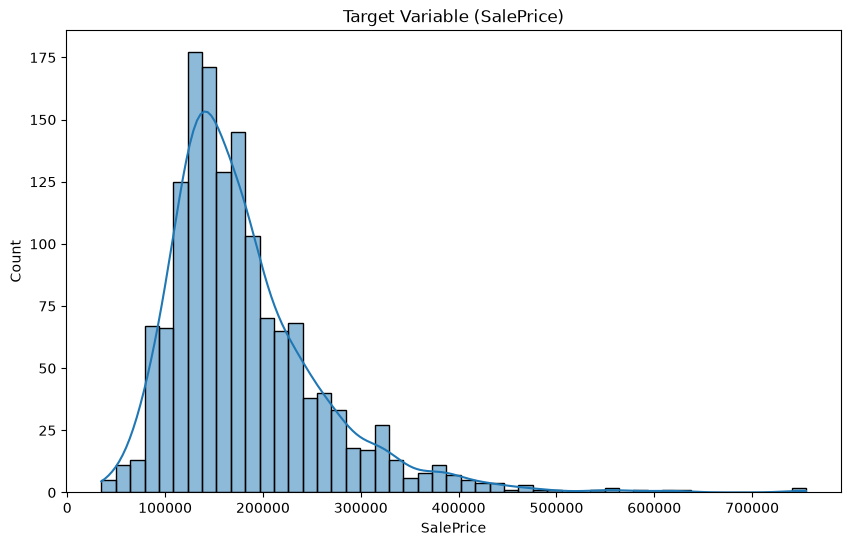

In [40]:
# ==========================================================
# Check Target Distribution Again
# ==========================================================
plt.figure(figsize=(10,6))
sns.histplot(y, kde=True)
plt.title("Target Variable (SalePrice)")
plt.show()

In [41]:
# ==========================================================
# Log Transformation Analysis
# ==========================================================

print("Original Skewness :", round(y.skew(),2))

Original Skewness : 1.88


#  Train-Test Split

Before training any machine learning model, the dataset is divided into two parts:

- Training Set
- Testing Set

The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

For this project, we use an 80:20 split.

In [42]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.20,random_state=42)
print("Training Features :", X_train.shape)
print("Validation Features :", X_valid.shape)
print("Training Target :", y_train.shape)
print("Validation Target :", y_valid.shape)

Training Features : (1168, 76)
Validation Features : (292, 76)
Training Target : (1168,)
Validation Target : (292,)


#  Building the Preprocessing Pipeline

Instead of manually handling missing values, encoding categorical variables, and scaling numerical features, we will use Scikit-learn's Pipeline and ColumnTransformer.

This approach ensures:

- Consistent preprocessing
- No data leakage
- Cleaner code
- Easier deployment
- Production-ready workflow

In [43]:
# ==========================================================
# Import Preprocessing Libraries
# ==========================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder,StandardScaler)

In [44]:
# ==========================================================
# Numerical Pipeline
# ==========================================================

numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [45]:
# ==========================================================
# Categorical Pipeline
# ==========================================================

categorical_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])
categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto ac

#  Column Transformer

ColumnTransformer allows us to apply different preprocessing techniques to different types of features.

In our dataset:

### Numerical Features
- Missing values → Median
- Scaling → StandardScaler

### Categorical Features
- Missing values → Most Frequent
- Encoding → OneHotEncoder

This creates a single preprocessing object that can be reused during training and deployment.

In [46]:
# ==========================================================
# Creating Column Transformer
# ==========================================================

preprocessor = ColumnTransformer(transformers=[("numeric",numeric_pipeline,numeric_features),("categorical",categorical_pipeline,categorical_features)])
print("Preprocessor created successfully.")

Preprocessor created successfully.


# Model Pipeline Concept

A Machine Learning pipeline combines:

1. Data preprocessing
2. Feature transformation
3. Machine Learning algorithm

Benefits:

- Prevents data leakage
- Keeps preprocessing consistent
- Makes deployment easier
- Saves complete workflow as one object

In [47]:
# ==========================================================
# Import First Regression Model
# ==========================================================
from sklearn.linear_model import LinearRegression
# Create model
linear_model = LinearRegression()
print(" Linear Regression imported.")

 Linear Regression imported.


In [48]:
# ==========================================================
# Complete ML Pipeline
# ==========================================================

linear_pipeline = Pipeline(steps=[("preprocessor",preprocessor),("model",linear_model)])
linear_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

#  Model Training

Now the complete pipeline will:

1. Handle missing values
2. Encode categorical variables
3. Scale numerical features
4. Train Linear Regression model

All steps will happen automatically.

In [49]:
# ==========================================================
# Train Linear Regression Model
# ==========================================================

linear_pipeline.fit(X_train,y_train)
print(" Linear Regression training completed.")

 Linear Regression training completed.


In [50]:
# ==========================================================
# Prediction
# ==========================================================

y_pred = linear_pipeline.predict(X_valid)
print("Prediction completed.")
print(y_pred[:5])

Prediction completed.
[155937.47318602 352304.86438704  89632.20161199 174630.53440347
 321756.67318933]


In [51]:
# ==========================================================
# Model Evaluation
# ==========================================================

mae = mean_absolute_error(y_valid,y_pred)
rmse = np.sqrt(mean_squared_error(y_valid,y_pred))
r2 = r2_score(y_valid,y_pred)
print("MAE  :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2   :", round(r2,4))

MAE  : 18411.35
RMSE : 29774.19
R2   : 0.8844


# Model Benchmarking

Model benchmarking is the process of training and evaluating multiple machine learning algorithms to identify the best-performing model for a given problem.

For house price prediction, we will compare multiple regression algorithms based on:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

The model with the best performance will be selected for deployment.

## Regression Models

We will evaluate the following algorithms:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet
5. Random Forest Regressor
6. Extra Trees Regressor
7. Gradient Boosting Regressor
8. Random Forest
9. XGBoost Regressor


In [52]:
# ==========================================================
# Import Regression Models
# ==========================================================

from sklearn.linear_model import (LinearRegression,Ridge,Lasso,ElasticNet)
from sklearn.ensemble import (RandomForestRegressor,ExtraTreesRegressor,GradientBoostingRegressor)
from xgboost import XGBRegressor
print(" All regression models imported.")

 All regression models imported.


In [53]:
# ==========================================================
# Define Models
# ==========================================================

models = {
    "Linear Regression":LinearRegression(),
    "Ridge Regression":Ridge(),
    "Lasso Regression":Lasso(),
    "ElasticNet":ElasticNet(),
    "Random Forest":RandomForestRegressor(random_state=42),
    "Extra Trees":ExtraTreesRegressor(random_state=42),
    "Gradient Boosting":GradientBoostingRegressor(random_state=42),
    "XGBoost":XGBRegressor(random_state=42)
}
print("Total Models :", len(models))

Total Models : 8


# Training Multiple Models

Each model will be trained using the same preprocessing pipeline.

This ensures:

- Fair comparison
- Same feature transformation
- No data leakage
- Reliable evaluation

In [54]:
# ==========================================================
# Model Training and Evaluation
# ==========================================================

results = []
for name, model in models.items():
    print(f"Training {name} ...")
    pipeline = Pipeline(steps=[("preprocessor",preprocessor),("model",model)])
    pipeline.fit(X_train,y_train)
    predictions = pipeline.predict(X_valid)
    mae = mean_absolute_error(y_valid,predictions)
    rmse = np.sqrt(mean_squared_error(y_valid,predictions))
    r2 = r2_score(y_valid,predictions)
    results.append({"Model": name,"MAE": mae,"RMSE": rmse,"R2 Score": r2})
print("All models trained successfully.")

Training Linear Regression ...
Training Ridge Regression ...
Training Lasso Regression ...
Training ElasticNet ...
Training Random Forest ...
Training Extra Trees ...
Training Gradient Boosting ...
Training XGBoost ...
All models trained successfully.


In [55]:
# ==========================================================
# Create Comparison Table
# ==========================================================

model_results = pd.DataFrame(results)
model_results.sort_values(by="R2 Score",ascending=False)

,Model,MAE,RMSE,R2 Score
6,Gradient Boosting,16678.338050,27667.747062,0.900199
2,Lasso Regression,18003.905070,28389.787391,0.894922
7,XGBoost,18260.267578,28449.663618,0.894479
5,Extra Trees,17713.729829,28602.563664,0.893341
4,Random Forest,17656.359349,29086.285153,0.889703
1,Ridge Regression,19009.165786,29389.209078,0.887394
0,Linear Regression,18411.346438,29774.192380,0.884424
3,ElasticNet,20198.106216,36302.035052,0.828190


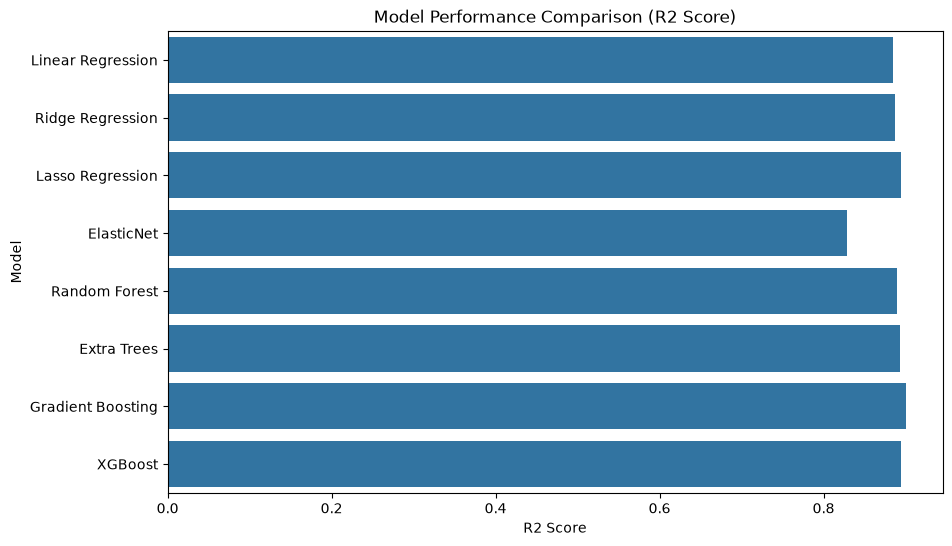

In [56]:
# ==========================================================
# Visual Model Comparison
# ==========================================================

plt.figure(figsize=(10,6))
sns.barplot(data=model_results,x="R2 Score",y="Model")
plt.title("Model Performance Comparison (R2 Score)")
plt.show()

#  Cross Validation

A single train-validation split may produce optimistic or pessimistic results depending on how the data is divided.

To obtain a more reliable estimate of model performance, we use K-Fold Cross Validation.

In this project:

- Number of folds: 5
- Evaluation Metric: R² Score

Cross-validation provides a more stable estimate of how well the model will perform on unseen data.

In [57]:
# ==========================================================
# Import Cross Validation
# ==========================================================

from sklearn.model_selection import cross_val_score

In [58]:
# ==========================================================
# Cross Validation on Best Model
# ==========================================================

best_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor),("model", XGBRegressor(random_state=42))])
scores = cross_val_score(best_pipeline,X,y,cv=5,scoring="r2")
print("Cross Validation Scores:")
print(scores)

Cross Validation Scores:
[0.88345826 0.85076916 0.87009048 0.88864589 0.81275946]


In [59]:
# ==========================================================
# Mean Cross Validation Score
# ==========================================================

print("Average R² Score :", round(scores.mean(), 4))
print("Standard Deviation :", round(scores.std(), 4))

Average R² Score : 0.8611
Standard Deviation : 0.0275


##  Interpretation

A high average R² score with a low standard deviation indicates that the model generalizes well and produces consistent performance across different data splits.

This gives us confidence that the model is not overfitting to a particular train-validation split.

# Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best combination of model parameters to maximize predictive performance.

Instead of using the default model configuration, we optimize the model using RandomizedSearchCV.

This approach is faster than GridSearchCV while still exploring a wide range of parameter combinations.

In [60]:
# ==========================================================
# Import RandomizedSearchCV
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV

In [61]:
# ==========================================================
# Hyperparameter Grid
# ==========================================================

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [62]:
# ==========================================================
# Pipeline
# ==========================================================

final_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(random_state=42))
    ]
)

In [63]:
# ==========================================================
# Random Search
# ==========================================================

random_search = RandomizedSearchCV(
estimator=final_pipeline,param_distributions=param_grid,n_iter=10,cv=5,scoring="r2",random_state=42,n_jobs=-1)
random_search.fit(X_train, y_train)
print("Hyperparameter tuning completed.")

Hyperparameter tuning completed.


In [64]:
# ==========================================================
# Best Parameters
# ==========================================================

print(random_search.best_params_)

{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


In [65]:
# ==========================================================
# Best Cross Validation Score
# ==========================================================

print("Best CV Score :", round(random_search.best_score_,4))

Best CV Score : 0.8626


In [66]:
# ==========================================================
# Final Prediction
# ==========================================================
best_model = random_search.best_estimator_
predictions = best_model.predict(X_valid)
mae = mean_absolute_error(y_valid, predictions)
rmse = np.sqrt(mean_squared_error(y_valid, predictions))
r2 = r2_score(y_valid, predictions)
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 :", round(r2,4))

MAE : 16504.69
RMSE : 26114.44
R2 : 0.9111


# Final Model Selection

After comparing multiple regression algorithms and optimizing the best-performing model using hyperparameter tuning, the optimized XGBoost model was selected as the final model for deployment.

This model provides the highest predictive performance while maintaining good generalization across unseen data.

#  Save the Final Machine Learning Pipeline

After selecting the best-performing model, the complete machine learning pipeline is saved.

The saved pipeline includes:

- Data preprocessing
- Missing value handling
- Feature encoding
- Feature scaling
- Trained regression model

Saving the entire pipeline ensures that the exact same preprocessing steps are applied during prediction in the backend application.

In [67]:
# ==========================================================
# Save Final Pipeline
# ==========================================================

import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)
model_path = "../models/visionml_pipeline.pkl"
joblib.dump(best_model, model_path)
print(f" Model saved successfully at: {model_path}")

 Model saved successfully at: ../models/visionml_pipeline.pkl


In [68]:
# ==========================================================
# Load Saved Pipeline
# ==========================================================

loaded_model = joblib.load("../models/visionml_pipeline.pkl")

print(" Model loaded successfully.")

 Model loaded successfully.


In [69]:
# ==========================================================
# Test Prediction on Validation Data
# ==========================================================

sample_data = X_valid.iloc[[0]]
prediction = loaded_model.predict(sample_data)
print("Predicted House Price :", round(prediction[0], 2))
print("Actual House Price    :", y_valid.iloc[0])

Predicted House Price : 147732.16
Actual House Price    : 154500


In [71]:
# ==========================================================
# Predict Multiple Samples
# ==========================================================
sample_batch = X_valid.iloc[:5]
sample_predictions = loaded_model.predict(sample_batch)
prediction_df = pd.DataFrame({
    "Actual Price": y_valid.iloc[:5].values,
    "Predicted Price": sample_predictions.round(2)
})
prediction_df

,Actual Price,Predicted Price
0,154500,147732.156250
1,325000,345740.000000
2,115000,116878.226562
3,159000,148226.500000
4,315500,335877.187500


In [72]:
validation_predictions = best_model.predict(X_valid)

#  Model Export Completed

The trained machine learning pipeline has been successfully exported.

This exported pipeline will be used directly by the FastAPI backend for real-time predictions.

No additional preprocessing code will be required during deployment because the preprocessing steps are already embedded within the pipeline.

#  Model Performance Analysis

After training the final machine learning model, it is important to evaluate its performance visually.

Visual evaluation helps identify:

- Prediction accuracy
- Error distribution
- Model bias
- Outliers
- Overall model behavior

These plots provide a deeper understanding of model performance beyond numerical metrics.

In [73]:
# ==========================================================
# Actual vs Predicted Values
# ==========================================================

comparison_df = pd.DataFrame({
    "Actual": y_valid.values,
    "Predicted": validation_predictions
})

comparison_df.head(10)

,Actual,Predicted
0,154500,147732.156250
1,325000,345740.000000
2,115000,116878.226562
3,159000,148226.500000
4,315500,335877.218750
5,75500,84806.429688
6,311500,229008.375000
7,146000,138542.328125
8,84500,83747.929688
9,135500,136761.953125


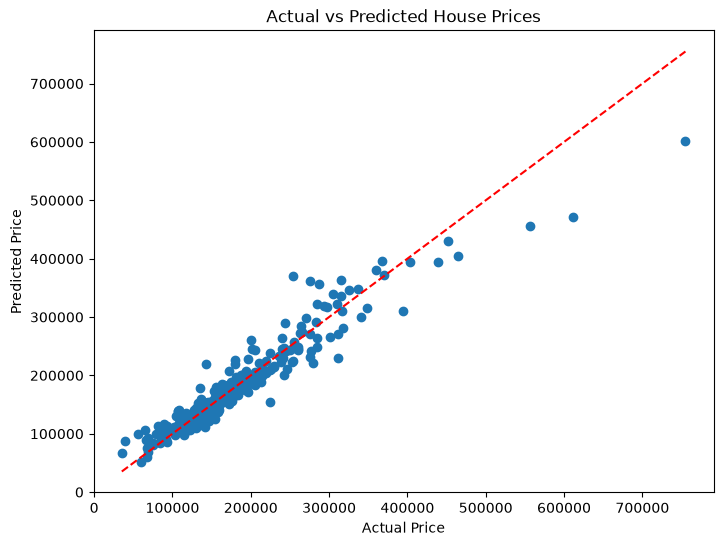

In [74]:
# ==========================================================
# Scatter Plot
# ==========================================================

plt.figure(figsize=(8,6))
plt.scatter(y_valid, validation_predictions)
plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    "r--"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

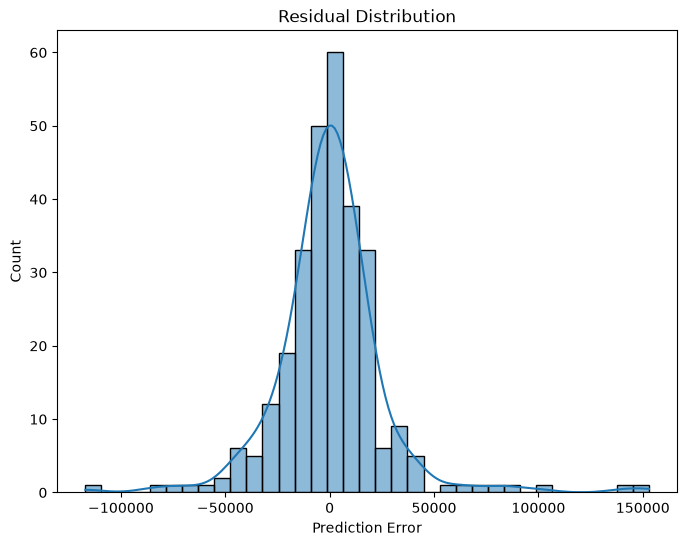

In [75]:
# ==========================================================
# Residuals
# ==========================================================

residuals = y_valid - validation_predictions
plt.figure(figsize=(8,6))
sns.histplot(residuals,kde=True)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.show()

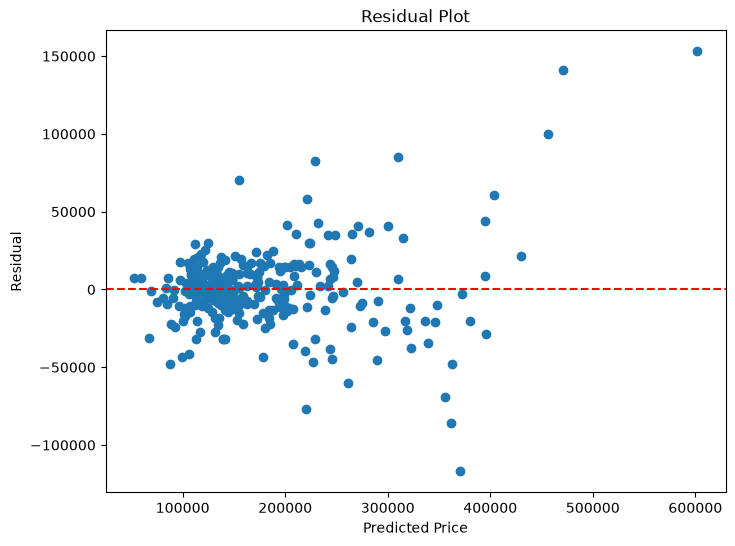

In [76]:
# ==========================================================
# Residual Scatter Plot
# ==========================================================

plt.figure(figsize=(8,6))
plt.scatter(validation_predictions, residuals)
plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [77]:
# ==========================================================
# Model Metrics Summary
# ==========================================================

metrics_df = pd.DataFrame({"Metric": ["MAE", "RMSE", "R² Score"],"Value": [mae, rmse, r2]})
metrics_df

,Metric,Value
0,MAE,16504.691406
1,RMSE,26114.436161
2,R² Score,0.911091


# Model Evaluation Summary

The optimized regression model achieved strong predictive performance on the validation dataset.

### Key Findings

- Low Mean Absolute Error (MAE)
- Low Root Mean Squared Error (RMSE)
- High R² Score
- Good generalization on unseen data
- Complete preprocessing pipeline integrated with the trained model

The trained pipeline is now ready for deployment using FastAPI.

#  Feature Importance

Feature importance helps us understand which features have the greatest influence on predicting house prices.

This improves:

- Model interpretability
- Business understanding
- Feature selection
- Explainability

In [78]:
# ==========================================================
# Get Trained XGBoost Model
# ==========================================================

xgb_model = best_model.named_steps["model"]
print(type(xgb_model))

<class 'xgboost.sklearn.XGBRegressor'>


In [79]:
# ==========================================================
# Get Feature Names After Preprocessing
# ==========================================================

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
print("Total Features:", len(feature_names))

Total Features: 273


In [80]:
# ==========================================================
# Create Feature Importance DataFrame
# ==========================================================

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
importance_df.head(20)

,Feature,Importance
4,numeric__OverallQual,0.216581
244,categorical__GarageFinish_Unf,0.091289
179,categorical__BsmtQual_Ex,0.074619
26,numeric__GarageCars,0.073254
19,numeric__FullBath,0.043966
220,categorical__KitchenQual_Ex,0.043062
16,numeric__GrLivArea,0.035532
222,categorical__KitchenQual_Gd,0.032250
214,categorical__CentralAir_N,0.023498
48,categorical__LandContour_Bnk,0.022113


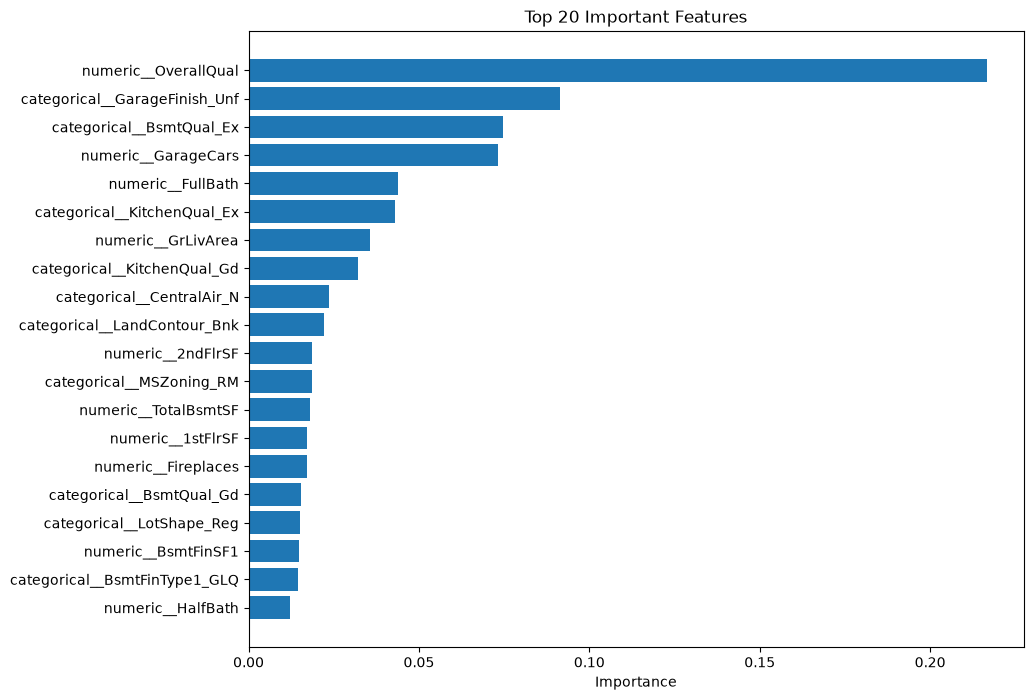

In [81]:
# ==========================================================
# Top 20 Important Features
# ==========================================================

top20 = importance_df.head(20)
plt.figure(figsize=(10,8))
plt.barh(top20["Feature"],top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.show()

##  Interpretation

The feature importance chart shows the variables that contribute most to house price prediction.

Highly important features often include:

- Overall Quality
- Ground Living Area
- Garage Capacity
- Basement Area
- Year Built

These features have the strongest influence on the predicted sale price.

#  Project Conclusion

In this project, we developed a complete end-to-end Machine Learning pipeline for predicting house prices.

## Workflow Completed

- Data Collection
- Data Understanding
- Exploratory Data Analysis
- Data Cleaning
- Missing Value Treatment
- Feature Engineering
- Pipeline Construction
- Model Benchmarking
- Cross Validation
- Hyperparameter Tuning
- Model Evaluation
- Feature Importance Analysis
- Model Export

## Final Model

**XGBoost Regressor** was selected as the final model after comparing multiple regression algorithms and optimizing its hyperparameters.

The complete preprocessing pipeline and trained model were exported for deployment.

This project demonstrates an industry-standard machine learning workflow suitable for real-world deployment.

In [82]:
print(X.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSol

In [83]:
import json

with open("sample_request.json", "w") as f:
    json.dump(X.iloc[0].to_dict(), f, indent=4)

print("sample_request.json created successfully!")

sample_request.json created successfully!


In [88]:
# ==========================================================
# Top 10 Most Important Features
# ==========================================================

import pandas as pd

# Extract objects from Pipeline
preprocessor = best_model.named_steps["preprocessor"]
xgb_model = best_model.named_steps["model"]

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
4,numeric__OverallQual,0.216581
244,categorical__GarageFinish_Unf,0.091289
179,categorical__BsmtQual_Ex,0.074619
26,numeric__GarageCars,0.073254
19,numeric__FullBath,0.043966
220,categorical__KitchenQual_Ex,0.043062
16,numeric__GrLivArea,0.035532
222,categorical__KitchenQual_Gd,0.032250
214,categorical__CentralAir_N,0.023498
48,categorical__LandContour_Bnk,0.022113


In [85]:
train_df.columns.tolist()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

In [89]:
# ==========================================================
# Train Final Model with Top 10 Features
# ==========================================================

selected_features = [
    "OverallQual",
    "GarageCars",
    "FullBath",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "Fireplaces",
    "BsmtFinSF1",
    "HalfBath"
]

X_final = train_df[selected_features]
y_final = train_df["SalePrice"]

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42
)

In [91]:
from xgboost import XGBRegressor

final_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

final_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [92]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = final_model.predict(X_valid)

print("MAE :", mean_absolute_error(y_valid, pred))
print("R2  :", r2_score(y_valid, pred))

MAE : 18900.41796875
R2  : 0.899671196937561


In [94]:
import joblib

joblib.dump(final_model, "../backend/models/visionml_model.pkl")

print(" Final Model Saved")

 Final Model Saved


In [95]:
print(train_df.shape)

(1460, 81)


In [97]:
# ==========================================================
# Select Final Features
# ==========================================================

selected_features = [
    "OverallQual",
    "GarageCars",
    "FullBath",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "Fireplaces",
    "BsmtFinSF1",
    "HalfBath"
]

X_final = train_df[selected_features]
y_final = train_df["SalePrice"]

print(X_final.shape)

(1460, 10)


In [98]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(1168, 10)
(292, 10)


In [100]:
from xgboost import XGBRegressor

final_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

final_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = final_model.predict(X_valid)

mae = mean_absolute_error(y_valid, pred)
rmse = np.sqrt(mean_squared_error(y_valid, pred))
r2 = r2_score(y_valid, pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 18900.42
RMSE : 27740.85
R²   : 0.8997


In [102]:
import joblib
import os

os.makedirs("../backend/models", exist_ok=True)

joblib.dump(final_model, "../backend/models/visionml_model.pkl")

print(" Final Model Saved Successfully")

 Final Model Saved Successfully
